In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [3]:
annual_value_adjusted = pd.read_csv("data/outputs/annual_ca_port",
                                    index_col =0, parse_dates = [1])
quarterly_value_adjusted = pd.read_csv('data/outputs/quarter_ca_port',
                                    index_col =0, parse_dates = [1])
band_value_adjusted = pd.read_csv("data/outputs/quarter_band_ca_port",
                                    index_col =0, parse_dates = [1])
asset_data = pd.read_csv("data/processed/daily_returns.csv",
                         parse_dates = [0])


In [4]:
annual_weights = pd.read_csv("data/outputs/annually_rebalanced_weights", 
                             index_col = 0, parse_dates = [1])
quarterly_weights = pd.read_csv("data/outputs/quarterly_rebalanced_weights", 
                                index_col = 0, parse_dates = [1])
band_weights = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights", 
                           index_col = 0, parse_dates = [1])
daily_returns = pd.read_csv("data/processed/daily_returns.csv", parse_dates = [0])

In [5]:
asset_data = daily_returns[daily_returns['Date'].isin(annual_value_adjusted['Date'])].reset_index().drop(columns=['index'])

## Return Contributions

In [6]:
def daily_asset_contributions(weights_df, asset_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    returns_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = asset_df[asset_df['Date'].between(start, end)]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        for row in range(len(period_data)):

            returns_by_asset = weights.iloc[0] * period_data.iloc[row]

            returns_by_asset['Date'] = period_data['Date'].iloc[row]

            returns_list.append(returns_by_asset)

    return pd.DataFrame(returns_list).set_index('Date')


In [7]:

annual_portfolio_asset_contributions = daily_asset_contributions(annual_weights, asset_data)
quarterly_portfolio_asset_contributions = daily_asset_contributions(quarterly_weights, asset_data)
banded_portfolio_asset_contributions = daily_asset_contributions(band_weights, asset_data)

In [8]:
def asset_contributions_to_returns(portfolio_df, asset_contribution_df):
    weights_sums = []
    total_return = portfolio_df['portfolio_return'].sum()

    for col in asset_contribution_df.columns:
        name = asset_contribution_df[col].name
        col_sum = asset_contribution_df[col].sum()
        percent_cont = col_sum / total_return
        weights_sums.append({
            'asset' : name, 
            'total_return_contribution' : col_sum,
            'percent_contribution' : percent_cont
        })

    return pd.DataFrame(weights_sums).set_index('asset')


In [9]:
asset_contribution_table_annual = asset_contributions_to_returns(annual_value_adjusted, annual_portfolio_asset_contributions)
asset_contribution_table_quarterly = asset_contributions_to_returns(quarterly_value_adjusted, quarterly_portfolio_asset_contributions)
asset_contribution_table_band = asset_contributions_to_returns(band_value_adjusted, banded_portfolio_asset_contributions)

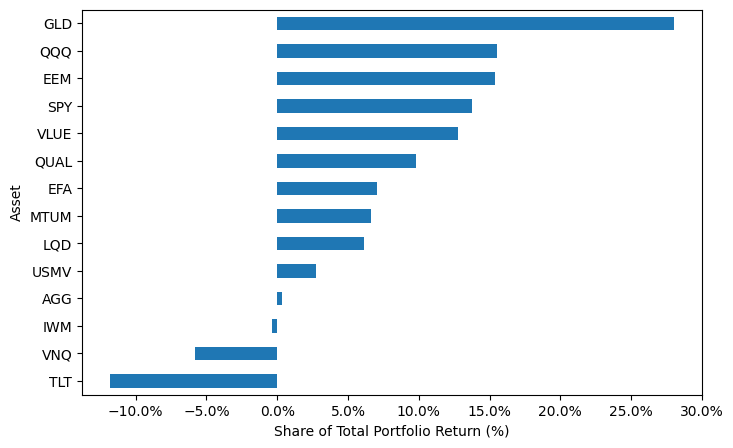

In [10]:
asset_contribution_table_band = asset_contribution_table_band.sort_values('percent_contribution', ascending= True)
fig, ax = plt.subplots(figsize=(8, 5))
asset_contribution_table_band.plot(kind = 'barh', y = 'percent_contribution', legend = False, ax = ax)
plt.xlabel('Share of Total Portfolio Return (%)')
plt.ylabel('Asset')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

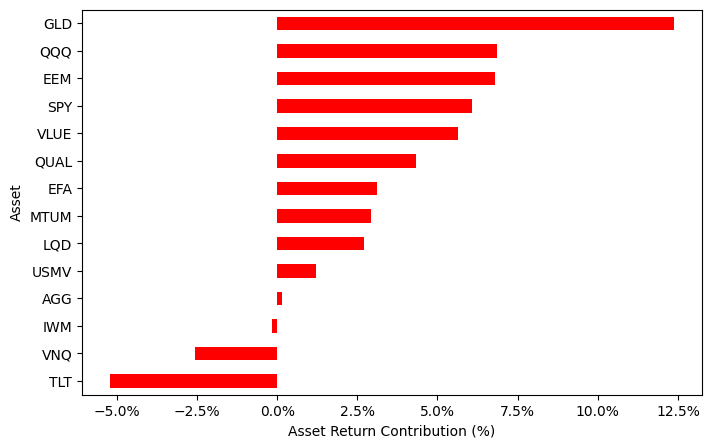

In [38]:
asset_contribution_table_band = asset_contribution_table_band.sort_values('total_return_contribution')
fig, ax = plt.subplots(figsize=(8, 5))
asset_contribution_table_band.plot(kind = 'barh', y = 'total_return_contribution', ax = ax, color = 'red', legend = False)
plt.ylabel('Asset')
plt.xlabel('Asset Return Contribution (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

In [12]:
portfolio_groups = {
    "Dom_Eq": ['SPY', 'QQQ', 'IWM'],
    "Intl_Eq": ['EFA', 'EEM'],
    "Fixed_Inc": ['AGG', 'TLT', 'LQD'],
    "Alt": ['GLD', 'VNQ'],
    "Factor": ['MTUM', 'VLUE', 'QUAL', 'USMV']
}
ticker_asset_class = {
    ticker: group
    for group, tickers in portfolio_groups.items()
    for ticker in tickers
}

In [13]:
asset_class_contributions_annual = annual_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore
asset_class_contributions_quarterly = quarterly_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore
asset_class_contributions_band = banded_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore

In [14]:
def class_contributions_to_return(df, portfolio_df):
    total_return = portfolio_df['portfolio_return'].sum()

    asset_contribution_totals = []
    for col in df.columns:
        name = df[col].name
        col_sum = df[col].sum()
        percent_cont = col_sum / total_return
        asset_contribution_totals.append({
            'class' : name, 
            'total_return_contribution' : col_sum,
            'percent_contribution' : percent_cont
        })

    return pd.DataFrame(asset_contribution_totals).set_index('class')


In [15]:

class_contribution_table_annual = class_contributions_to_return(asset_class_contributions_annual, annual_value_adjusted)
class_contribtuion_table_quarterly = class_contributions_to_return(asset_class_contributions_quarterly, quarterly_value_adjusted)
class_contribtuion_table_band = class_contributions_to_return(asset_class_contributions_band, band_value_adjusted)

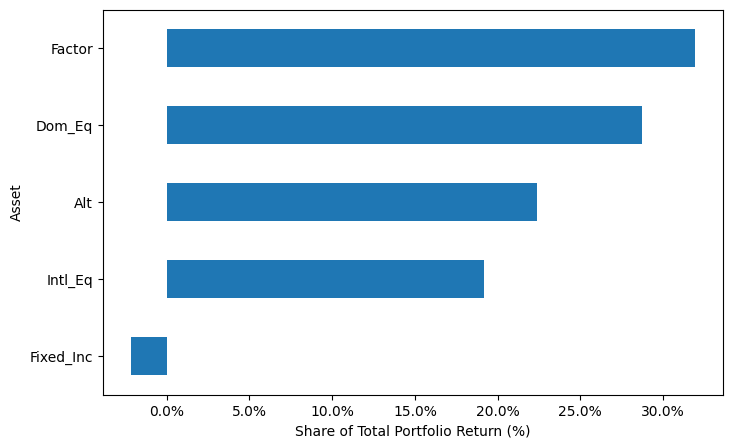

In [16]:
class_contribtuion_table_quarterly = class_contribtuion_table_quarterly.sort_values('percent_contribution', ascending= True)
fig, ax = plt.subplots(figsize=(8, 5))
class_contribtuion_table_quarterly.plot(kind = 'barh', y = 'percent_contribution', legend = False, ax = ax)
plt.xlabel('Share of Total Portfolio Return (%)')
plt.ylabel('Asset')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

## Risk Contributions

In [34]:
risk_data = asset_data.copy()
value_vars = risk_data.columns.drop('Date')

long_asset_data = risk_data.melt(
    id_vars='Date',
    value_vars=value_vars,
    var_name='asset',
    value_name='return'
)

long_asset_data['year'] = long_asset_data['Date'].dt.year

annual_asset_volatility = (
    long_asset_data
    .groupby(['year', 'asset'], as_index=False)
    .agg(
        annual_vol=('return', lambda x: x.std() * np.sqrt(252))
    )
)

In [18]:
asset_copy = asset_data.copy()
asset_copy = asset_copy.set_index('Date').T.groupby(ticker_asset_class).sum().T.reset_index() # type: ignore

value_vars2 = asset_copy.columns

long_class_data = asset_copy.melt(
    id_vars='Date',
    value_vars=value_vars2,
    var_name='asset',
    value_name='return'
)

long_class_data['year'] = long_class_data['Date'].dt.year

annual_class_volatility = (
    long_class_data
    .groupby(['year', 'asset'], as_index=False)
    .agg(
        annual_vol=('return', lambda x: x.std() * np.sqrt(252))
    )
)

In [19]:
def annualized_portfolio_volatility(portfolio_df):

    portfolio_df['year'] = portfolio_df['Date'].dt.year

    volatility_df = (
    portfolio_df
    .groupby(['year'], as_index=False)
    .agg(
        annual_vol=('portfolio_return', lambda x: x.std() * np.sqrt(252))
        )
    )

    return volatility_df

In [20]:

avol_annual = annualized_portfolio_volatility(annual_value_adjusted)
avol_quarterly = annualized_portfolio_volatility(quarterly_value_adjusted)
avol_band = annualized_portfolio_volatility(band_value_adjusted)
avol_all = avol_annual.merge(
    avol_quarterly.merge(
        avol_band,
        on = 'year'
    ), on = 'year'
)
avol_all.columns = ['Year','Annually Rebalanced', 'Quarterly Rebalanced', 'Quarterly Reblanced w/ Band']

In [21]:
class_vol_table = annual_class_volatility.pivot(index = 'year', columns=['asset'], values='annual_vol').reset_index()
class_vol_table.columns = ['Year', 'Alternative Assets','Domestic Equity', 'Factor Equity','Fixed Income','International Equity']

In [22]:
def portfolio_risk_metrics(weights_df, asset_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    metrics_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = asset_df[asset_df['Date'].between(start, end)]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        covariance = period_data.set_index('Date').cov()

        period_std = np.sqrt(weights.iloc[0].T @ covariance @ weights.iloc[0])

        mcr = (covariance @ weights.iloc[0]) / period_std
        mcr.name = 'mcr'

        rc = mcr.T * weights.iloc[0]
        rc.name = 'rc'

        pcr = rc / period_std
        pcr.name = 'pcr'

        metrics = pd.concat([mcr, rc, pcr], axis = 1).reset_index(names='asset')
    
        metrics['date'] = start

        metrics_list.append(metrics)

    metrics_df = pd.concat(metrics_list, ignore_index=True)

    return metrics_df.set_index('date')

portfolio_risk_metrics(annual_weights, asset_data)

,asset,mcr,rc,pcr
date,,,,
2022-01-03,AGG,0.002975,4.462541e-04,4.233766e-02
2022-01-03,EEM,0.010287,0.000000e+00,0.000000e+00
2022-01-03,EFA,0.012212,1.831757e-03,1.737850e-01
2022-01-03,GLD,0.003155,0.000000e+00,0.000000e+00
2022-01-03,IWM,0.015833,8.995169e-19,8.534026e-17
...,...,...,...,...
2026-01-02,SPY,0.007478,1.121647e-03,1.241176e-01
2026-01-02,TLT,0.002347,0.000000e+00,0.000000e+00
2026-01-02,USMV,0.002242,1.120882e-04,1.240329e-02


In [23]:
risk_metrics_annual = portfolio_risk_metrics(annual_weights, asset_data)
risk_metrics_quarterly = portfolio_risk_metrics(quarterly_weights, asset_data)
risk_metrics_band = portfolio_risk_metrics(band_weights, asset_data)

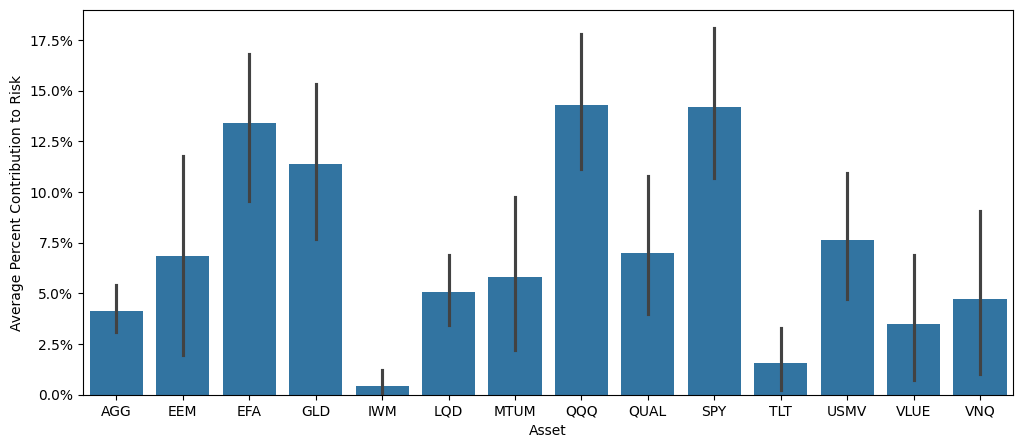

In [24]:
fig, ax = plt.subplots(figsize =(12,5))

sns.barplot(x = 'asset', y = 'pcr', data = risk_metrics_band)
plt.ylabel('Average Percent Contribution to Risk')
plt.xlabel('Asset')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

In [25]:
risk_metrics_annual['asset_class'] = risk_metrics_annual['asset'].map(ticker_asset_class)
risk_metrics_quarterly['asset_class'] = risk_metrics_quarterly['asset'].map(ticker_asset_class)
risk_metrics_band['asset_class'] = risk_metrics_band['asset'].map(ticker_asset_class)

In [26]:
risk_metrics_annual_grouped = (risk_metrics_annual
    .groupby(['date','asset_class'], as_index = False)
    .agg({
        'pcr' : 'sum',
        'rc' : 'sum'
        }))
risk_metrics_quarterly_grouped = (risk_metrics_quarterly
    .groupby(['date','asset_class'], as_index = False)
    .agg({
        'pcr' : 'sum',
        'rc' : 'sum'
        }))
risk_metrics_band_grouped = (risk_metrics_band
    .groupby(['date','asset_class'], as_index = False)
    .agg({
        'pcr' : 'sum',
        'rc' : 'sum'
        }))

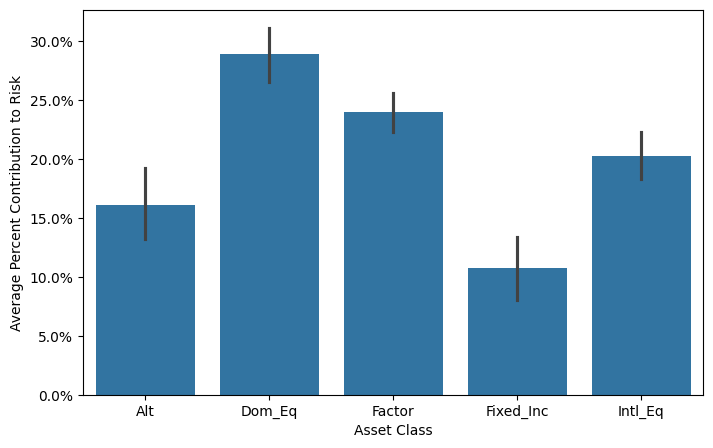

In [27]:
fig, ax = plt.subplots(figsize = (8,5))

sns.barplot(data = risk_metrics_band_grouped, x = 'asset_class', y = 'pcr')
plt.ylabel('Average Percent Contribution to Risk')
plt.xlabel('Asset Class')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

## Diversification Analysis

In [28]:
def eff_number_holdings(weights_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    enh_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        enh = 1 / np.sum(weights.iloc[0] ** 2)

        enh_list.append({
            'date' : start,
            'enh' : enh
        })

    enh_df = pd.DataFrame(enh_list)    

    return enh_df


In [29]:
annual_effective_holding = eff_number_holdings(annual_weights)
quarterly_effective_holding = eff_number_holdings(quarterly_weights)
band_effective_holding = eff_number_holdings(band_weights)

In [30]:
def eff_number_bets(weights_df, risk_df):

    enb_list = []

    risk_df = risk_df.copy()

    risk_df = risk_df.reset_index()

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = risk_df[risk_df['date'].between(start, end)]

        pcr = period_data['pcr']

        enb = 1 / np.sum(pcr**2)

        enb_list.append({
            'date' : start,
            'enb' : enb
            })
        
    return pd.DataFrame(enb_list)


In [31]:
annual_effective_bets = eff_number_bets(annual_weights, risk_metrics_annual)
quarterly_effective_bets = eff_number_bets(quarterly_weights, risk_metrics_quarterly)
band_effective_bets = eff_number_bets(band_weights, risk_metrics_band)

In [32]:
annual_diversification = annual_effective_holding.merge(
    annual_effective_bets,
    on = 'date'
)
quarterly_diversification = annual_effective_holding.merge(
    annual_effective_bets,
    on = 'date'
)
band_diversification = band_effective_holding.merge(
    band_effective_bets,
    on = 'date'
)

Text(0.5, 0, 'Date')

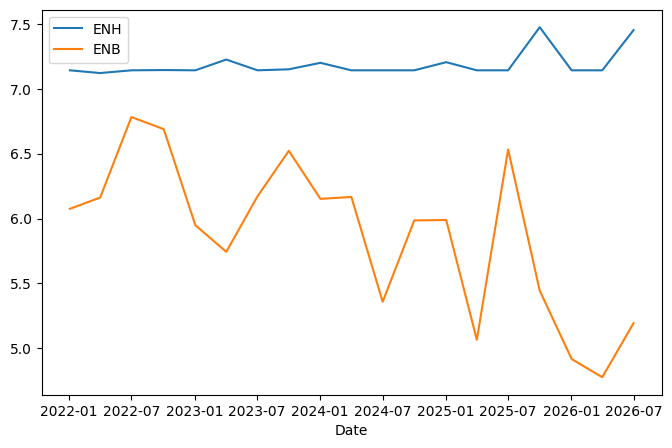

In [33]:
fig, ax = plt.subplots(figsize = (8,5))

sns.lineplot(x = 'date', y = 'enh', data = band_diversification, label = 'ENH')
sns.lineplot(x = 'date', y = 'enb', data = band_diversification, label = 'ENB')

plt.ylabel(None)
plt.xlabel('Date')